In [1]:
import pandas as pd

# Active learning performance figure
rounds = list(range(1, 9))
models = ["YOLOv8n", "YOLOv8s"] + ["YOLOv8m"] * 6
map_0_5 = [0.25, 0.33, 0.44, 0.6, 0.67, 0.70, 0.72, 0.73]
map_0_95 = [0.11, 0.17, 0.22, 0.35, 0.38, 0.39, 0.41, 0.43]

al_performance_df = pd.DataFrame(data={"Round": rounds, "Model": models, "mAP@0.5": map_0_5, "mAP@0.5:0.95": map_0_95})
al_performance_df

,Round,Model,mAP@0.5,mAP@0.5:0.95
0,1,YOLOv8n,0.25,0.11
1,2,YOLOv8s,0.33,0.17
2,3,YOLOv8m,0.44,0.22
3,4,YOLOv8m,0.60,0.35
4,5,YOLOv8m,0.67,0.38
5,6,YOLOv8m,0.70,0.39
6,7,YOLOv8m,0.72,0.41
7,8,YOLOv8m,0.73,0.43


2024-04-03 15:54:46,603 - py.warnings - WARNING - /home/daniel/git/cotton_flower_mot/.venv/lib/python3.10/site-packages/seaborn/rcmod.py:82: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(mpl.__version__) >= "3.0":

2024-04-03 15:54:46,603 - py.warnings - WARNING - /home/daniel/git/cotton_flower_mot/.venv/lib/python3.10/site-packages/setuptools/_distutils/version.py:345: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  other = LooseVersion(other)

2024-04-03 15:54:46,613 - py.warnings - WARNING - /home/daniel/git/cotton_flower_mot/.venv/lib/python3.10/site-packages/seaborn/cm.py:1582: MatplotlibDeprecationWarning: The register_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps.register(name)`` instead.
  mpl_cm.register_cmap(_name, _cmap)

2024-04-03 15:54:46,614 - py.warnings - WARNING - /home/daniel/git/cott

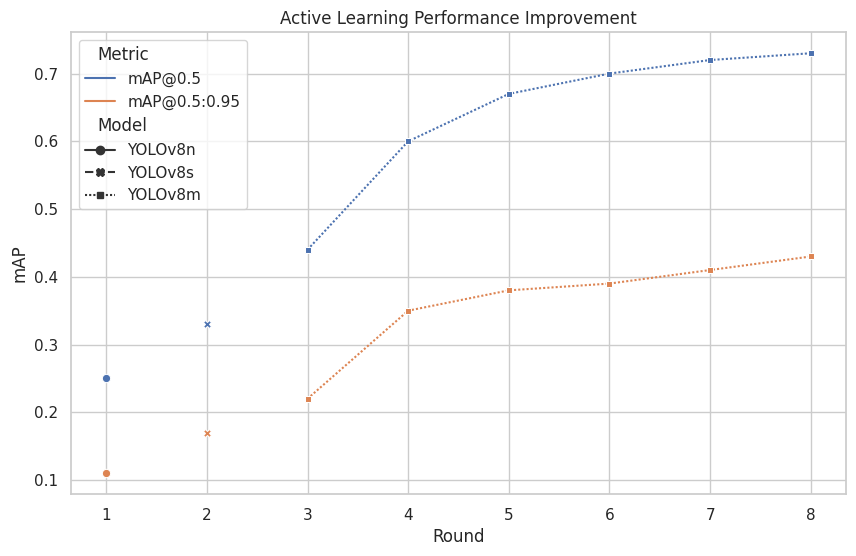

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set seaborn style
sns.set(style="whitegrid")

# Melt the DataFrame to have a single "Metric" column for different mAP types
al_performance_melted = al_performance_df.melt(id_vars=['Round', 'Model'], var_name='Metric', value_name='mAP')

# Create the line plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=al_performance_melted, x='Round', y='mAP', hue='Metric', style='Model', markers=True)
plt.title('Active Learning Performance Improvement')
plt.xlabel('Round')
plt.ylabel('mAP')
plt.show()

In [3]:
# Create ablation experiments plot.
ablation_data = pd.read_excel("Experiments.xlsx", sheet_name="Ablation", true_values={"Y"}, false_values={"N"})
ablation_data

,Int8,KF,Anchor Box,RoI Detection,2-Stage Association,Conf. Threshold,IoU Threshold,Death Window,Keyframe Period,Video,Unnamed: 10,HOTA,IDF1,Speed (FPS)
0,False,False,False,False,False,0.70,0.25,1,NaN,2022-08-23_ENGR,NaN,68.83,80.90,13.67
1,False,False,False,False,False,0.70,0.25,1,NaN,2021-08-25_SPL,NaN,47.29,66.08,19.04
2,False,False,False,False,True,0.70,0.25,1,NaN,2022-08-23_ENGR,NaN,68.83,80.90,18.71
3,False,False,False,False,True,0.70,0.25,1,NaN,2021-08-25_SPL,NaN,47.30,66.08,22.13
4,False,True,False,False,True,0.70,0.25,1,NaN,2022-08-23_ENGR,NaN,69.92,83.30,20.35
5,False,True,False,False,True,0.70,0.25,1,NaN,2021-08-25_SPL,NaN,48.55,69.51,22.79
6,False,True,True,False,True,0.70,0.25,1,NaN,2022-08-23_ENGR,NaN,69.92,83.30,19.80
7,False,True,True,False,True,0.70,0.25,1,NaN,2021-08-25_SPL,NaN,48.55,69.51,22.01
8,False,True,True,True,True,0.70,0.25,1,0.1,2022-08-23_ENGR,NaN,67.71,81.52,31.98
9,False,True,True,True,True,0.70,0.25,1,0.1,2021-08-25_SPL,NaN,46.73,67.43,71.75


In [4]:
def get_config(row: pd.Series) -> str:
    config = "Base"
    if row["Int8"]:
        config = "I"
    if row["2-Stage Association"]:
        if config == "I":
            config += "+2SA"
        else:
            # Replace the base specifier.
            config = "2SA"
    if row["KF"]:
        config += "+KF"
    if row["Anchor Box"]:
        config += "+AB"
    if row["RoI Detection"]:
        config += "+RoI"
    
    return config

ablation_data["Config"] = ablation_data.apply(get_config, axis=1)

2024-04-03 15:54:46,829 - py.warnings - WARNING - /home/daniel/git/cotton_flower_mot/.venv/lib/python3.10/site-packages/seaborn/rcmod.py:400: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(mpl.__version__) >= "3.0":

2024-04-03 15:54:46,830 - py.warnings - WARNING - /home/daniel/git/cotton_flower_mot/.venv/lib/python3.10/site-packages/setuptools/_distutils/version.py:345: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  other = LooseVersion(other)



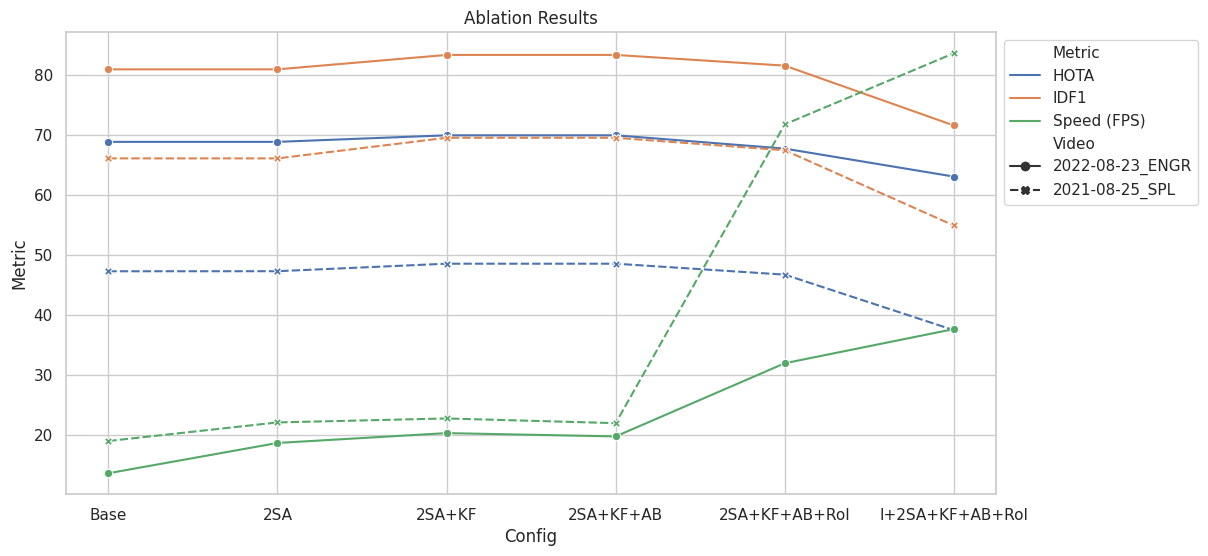

In [5]:
# Set seaborn style
sns.set(style="whitegrid")

# Melt the DataFrame to have a single "Metric" column for different metrics
ablation_data_slice = ablation_data[["Video", "HOTA", "IDF1", "Speed (FPS)", "Config"]]
ablation_data_melted = ablation_data_slice.melt(id_vars=['Config', 'Video'], var_name='Metric', value_name='Value')

# Create the line plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=ablation_data_melted, x='Config', y='Value', hue='Metric', style='Video', markers=True)
plt.title('Ablation Results')
plt.xlabel('Config')
plt.ylabel('Metric')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.show()


In [7]:
# Create parameter search plots.
search_data = pd.read_excel("Experiments.xlsx", sheet_name="Parameter Search")
search_data

,Conf. Threshold,IoU Threshold,Death Window,Keyframe Period,Video,Unnamed: 5,HOTA,IDF1,Speed (FPS)
0,0.200,0.25,1,0.10,2022-08-23_ENGR,NaN,45.40,52.35,48.20
1,0.200,0.25,1,0.10,2021-08-25_SPL,NaN,26.53,31.49,103.81
2,0.050,0.25,1,0.10,2022-08-23_ENGR,NaN,59.00,67.55,42.70
3,0.050,0.25,1,0.10,2021-08-25_SPL,NaN,32.47,44.30,95.18
4,0.100,0.50,1,0.10,2022-08-23_ENGR,NaN,55.68,63.66,41.33
5,0.100,0.50,1,0.10,2021-08-25_SPL,NaN,30.20,39.58,100.22
6,0.100,0.10,1,0.10,2022-08-23_ENGR,NaN,55.68,63.66,44.77
7,0.100,0.10,1,0.10,2021-08-25_SPL,NaN,30.20,39.58,97.55
8,0.100,0.25,2,0.10,2022-08-23_ENGR,NaN,55.68,63.66,43.87
9,0.100,0.25,2,0.10,2021-08-25_SPL,NaN,30.22,39.80,96.61


In [26]:
BASE_CONF = 0.1
BASE_IOU = 0.25
BASE_DW = 1
BASE_KFP = 0.1

# Melt all the metrics.
search_data_clean = search_data.drop("Unnamed: 5", axis=1)
search_data_melted = search_data_clean.melt(id_vars=search_data_clean.columns[:-3], var_name="Metric", value_name="Value")

base_conf = search_data_melted["Conf. Threshold"] == BASE_CONF
base_iou = search_data_melted["IoU Threshold"] == BASE_IOU
base_dw = search_data_melted["Death Window"] == BASE_DW
base_kfp = search_data_melted["Keyframe Period"] == BASE_KFP

search_conf = search_data_melted[base_iou & base_dw & base_kfp]
search_iou = search_data_melted[base_conf & base_dw & base_kfp]
search_dw = search_data_melted[base_conf & base_iou & base_kfp]
search_kfp = search_data_melted[base_conf & base_iou & base_dw]

2024-04-03 16:30:56,429 - py.warnings - WARNING - /home/daniel/git/cotton_flower_mot/.venv/lib/python3.10/site-packages/seaborn/rcmod.py:400: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(mpl.__version__) >= "3.0":

2024-04-03 16:30:56,496 - py.warnings - WARNING - /home/daniel/git/cotton_flower_mot/.venv/lib/python3.10/site-packages/pandas/core/dtypes/cast.py:1841: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])

2024-04-03 16:30:56,508 - py.warnings - WARNING - /home/daniel/git/cotton_flower_mot/.venv/lib/python3.10/site-packages/seaborn/categorical.py:381: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(mpl.__version__) < "3.0":

2024-04-03 16:30

<Figure size 1200x600 with 0 Axes>

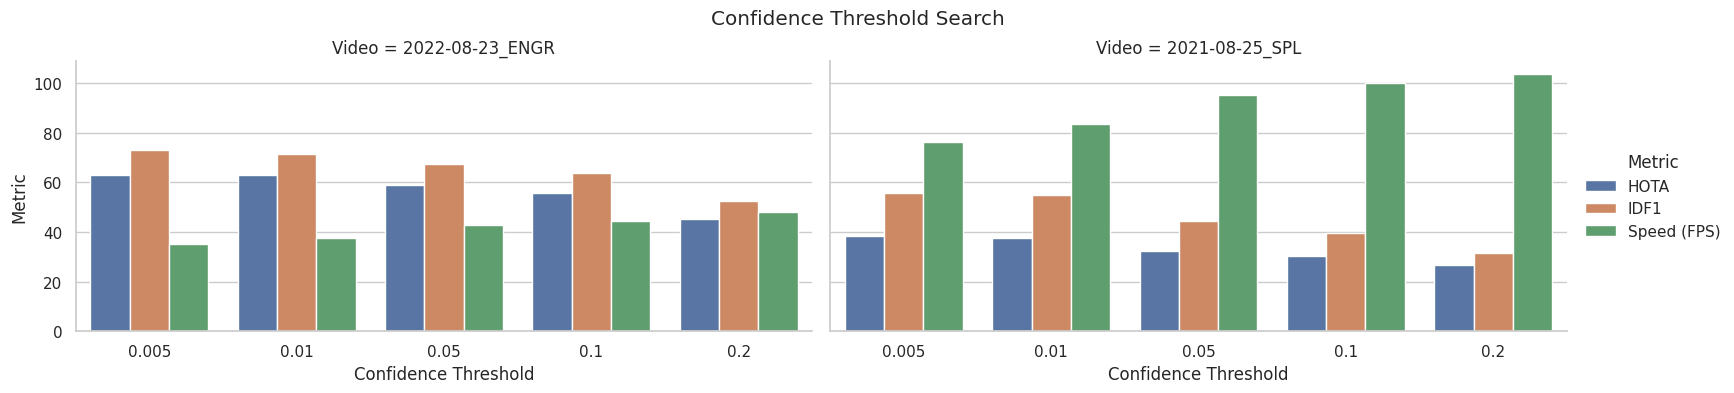

In [42]:
# Confidence threshold search plot
# Set seaborn style
sns.set(style="whitegrid")

# Create the bar plot.
plt.figure(figsize=(12, 6))
grid = sns.catplot(kind="bar", data=search_conf, x='Conf. Threshold', y='Value', hue='Metric', col='Video', height=4, aspect=2)
grid.fig.suptitle('Confidence Threshold Search')
# Adjust the layout to move the main title upwards
plt.subplots_adjust(top=0.85)
grid.set_axis_labels("Confidence Threshold", "Metric")
plt.show()

2024-04-03 16:34:53,653 - py.warnings - WARNING - /home/daniel/git/cotton_flower_mot/.venv/lib/python3.10/site-packages/seaborn/rcmod.py:400: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(mpl.__version__) >= "3.0":

2024-04-03 16:34:53,714 - py.warnings - WARNING - /home/daniel/git/cotton_flower_mot/.venv/lib/python3.10/site-packages/pandas/core/dtypes/cast.py:1841: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])

2024-04-03 16:34:53,723 - py.warnings - WARNING - /home/daniel/git/cotton_flower_mot/.venv/lib/python3.10/site-packages/seaborn/categorical.py:381: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(mpl.__version__) < "3.0":

2024-04-03 16:34

<Figure size 1200x600 with 0 Axes>

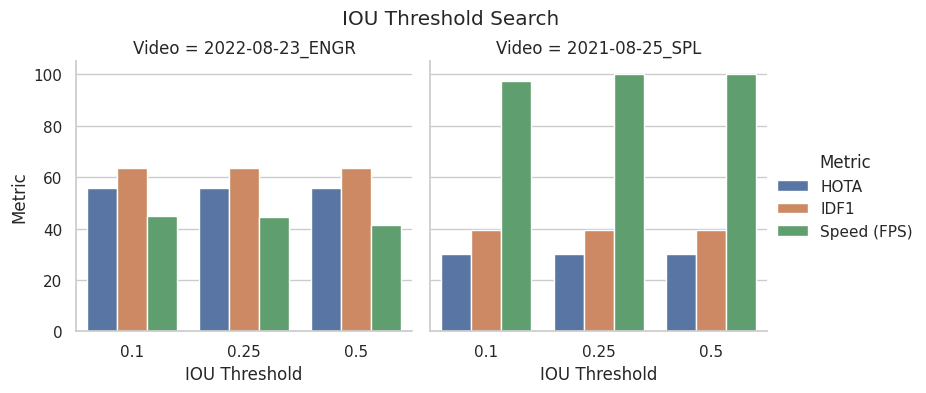

In [46]:
# IOU threshold search plot
# Set seaborn style
sns.set(style="whitegrid")

# Create the bar plot.
plt.figure(figsize=(12, 6))
grid = sns.catplot(kind="bar", data=search_iou, x='IoU Threshold', y='Value', hue='Metric', col='Video', height=4, aspect=1)
grid.fig.suptitle('IOU Threshold Search')
# Adjust the layout to move the main title upwards
plt.subplots_adjust(top=0.85)
grid.set_axis_labels("IOU Threshold", "Metric")
plt.show()

2024-04-03 16:34:57,858 - py.warnings - WARNING - /home/daniel/git/cotton_flower_mot/.venv/lib/python3.10/site-packages/seaborn/rcmod.py:400: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(mpl.__version__) >= "3.0":

2024-04-03 16:34:57,927 - py.warnings - WARNING - /home/daniel/git/cotton_flower_mot/.venv/lib/python3.10/site-packages/pandas/core/dtypes/cast.py:1841: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])

2024-04-03 16:34:57,933 - py.warnings - WARNING - /home/daniel/git/cotton_flower_mot/.venv/lib/python3.10/site-packages/seaborn/categorical.py:381: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(mpl.__version__) < "3.0":

2024-04-03 16:34

<Figure size 1200x600 with 0 Axes>

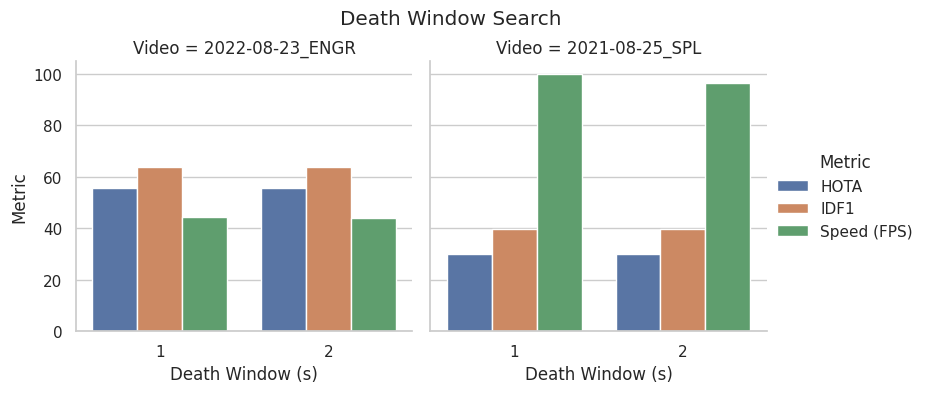

In [47]:
# Death window search plot
# Set seaborn style
sns.set(style="whitegrid")

# Create the bar plot.
plt.figure(figsize=(12, 6))
grid = sns.catplot(kind="bar", data=search_dw, x='Death Window', y='Value', hue='Metric', col='Video', height=4, aspect=1)
grid.fig.suptitle('Death Window Search')
# Adjust the layout to move the main title upwards
plt.subplots_adjust(top=0.85)
grid.set_axis_labels("Death Window (s)", "Metric")
plt.show()

2024-04-03 16:35:02,792 - py.warnings - WARNING - /home/daniel/git/cotton_flower_mot/.venv/lib/python3.10/site-packages/seaborn/rcmod.py:400: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(mpl.__version__) >= "3.0":

2024-04-03 16:35:02,855 - py.warnings - WARNING - /home/daniel/git/cotton_flower_mot/.venv/lib/python3.10/site-packages/pandas/core/dtypes/cast.py:1841: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])

2024-04-03 16:35:02,863 - py.warnings - WARNING - /home/daniel/git/cotton_flower_mot/.venv/lib/python3.10/site-packages/seaborn/categorical.py:381: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(mpl.__version__) < "3.0":

2024-04-03 16:35

<Figure size 1200x600 with 0 Axes>

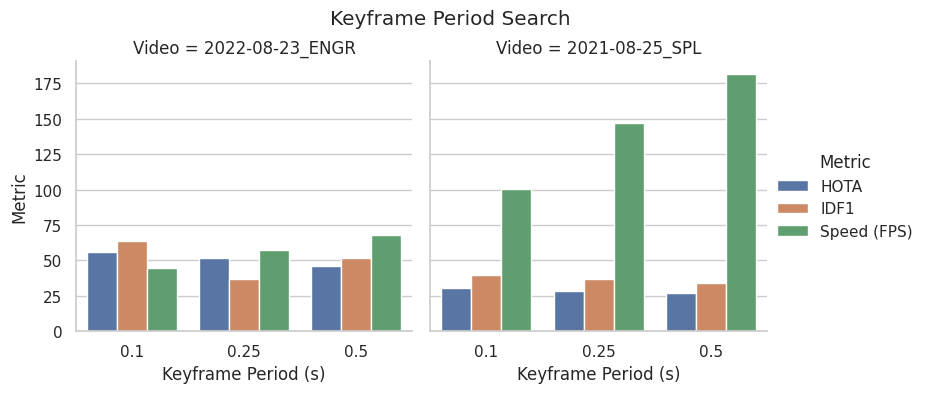

In [48]:
# Keyframe period search plot
# Set seaborn style
sns.set(style="whitegrid")

# Create the bar plot.
plt.figure(figsize=(12, 6))
grid = sns.catplot(kind="bar", data=search_kfp, x='Keyframe Period', y='Value', hue='Metric', col='Video', height=4, aspect=1)
grid.fig.suptitle('Keyframe Period Search')
# Adjust the layout to move the main title upwards
plt.subplots_adjust(top=0.85)
grid.set_axis_labels("Keyframe Period (s)", "Metric")
plt.show()

In [151]:
# Profiling pie chart
profile_data = pd.read_csv("profile_data_2021-08-25.txt", sep=" ", skipinitialspace=True, names=["Name", "Time", "Num Iters", "Cycle Time", "Cycle Freq"])
profile_data

,Name,Time,Num Iters,Cycle Time,Cycle Freq
0,match_frame_pair,408.737000,34229,0.011941,83.7432
1,detection,285.504000,34229,0.008341,119.8900
2,create_detection_inputs,0.632884,6198,0.000102,9793.2600
3,detection_model_full,185.042000,6198,0.029855,33.4950
4,filter_low_confidence,5.662960,34229,0.000165,6044.3600
5,update_tracks,36.150400,34229,0.001056,946.8510
6,update_active_tracks,20.779300,34229,0.000607,1647.2600
7,add_new_tracks,1.785230,34229,0.000052,19173.4000
8,update_saved_state,1.527790,34229,0.000045,22404.2000
9,roi_extraction,21.239600,28031,0.000758,1319.7500


In [152]:
def get_profiles(raw_profile_data: pd.DataFrame):
    raw_profile_data = raw_profile_data.copy()
    name = raw_profile_data["Name"]
    
    # Motion model is included in update_track time, so subtract that.
    raw_profile_data.loc[name == "update_tracks", "Time"] -= raw_profile_data.loc[name == "motion_model", "Time"].to_numpy()[0]
    
    profile_detection = raw_profile_data[(name == "detection") | (name == "create_detection_inputs") | (name == "filter_low_confidence")]
    profile_tracking = raw_profile_data[(name == "update_tracks") | (name == "fast_association") | (name == "motion_model") | (name == "slow_association")]
    profile_detection_details = raw_profile_data[(name == "detection_model_full") | (name == "roi_extraction") | (name == "detection_model_roi")]
    
    return profile_detection, profile_tracking, profile_detection_details

In [153]:
_NAME_MAP = {"detection_model_full": "Full Image Detector", "detection_model_roi": "RoI Detector", "roi_extraction": "Extract RoIs", 
             "update_tracks": "Track Bookkeeping", "slow_association": "GNN Association", "fast_association": "IOU Association",
             "motion_model": "Kalman Filter"}
def human_readable_names(name: str) -> str:
    return _NAME_MAP.get(name, name)

In [154]:
detection, tracking, detection_details = get_profiles(profile_data)

# Convert to human-readable names.
detection.loc[:, "Name"] = detection["Name"].apply(human_readable_names)
tracking.loc[:, "Name"] = tracking["Name"].apply(human_readable_names)
detection_details.loc[:, "Name"] = detection_details["Name"].apply(human_readable_names)

detection_time = detection.sum()["Time"]
tracking_time = tracking.sum()["Time"]

2024-04-04 12:12:53,433 - py.warnings - WARNING - /home/daniel/git/cotton_flower_mot/.venv/lib/python3.10/site-packages/pandas/core/dtypes/cast.py:1841: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])



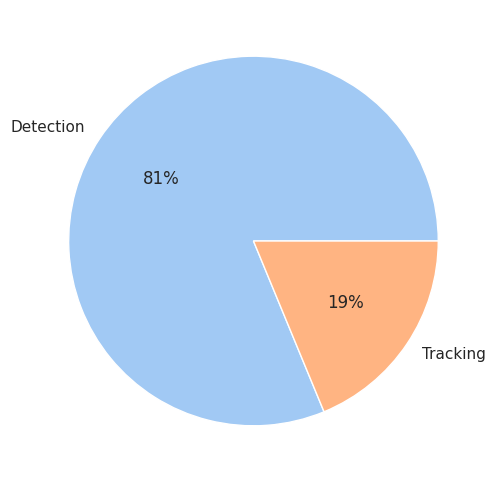

In [155]:
plt.figure(figsize=(6, 6))

# Overall detection and tracking
colors = sns.color_palette('pastel')[0:5]
plt.pie([detection_time, tracking_time], labels=["Detection", "Tracking"], autopct='%.0f%%', colors=colors)

plt.show()

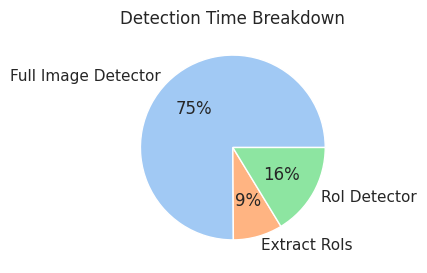

In [156]:
plt.figure(figsize=(3, 3))

# Detection breakdown
plt.pie(detection_details["Time"], labels=detection_details["Name"], autopct='%.0f%%', colors=colors)
plt.title("Detection Time Breakdown")
plt.show()

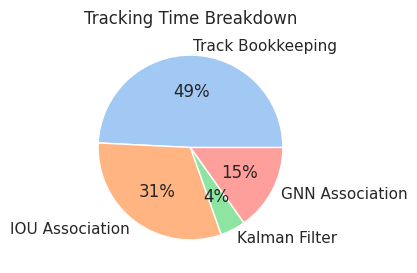

In [157]:
plt.figure(figsize=(3, 3))

# Tracking breakdown
plt.pie(tracking["Time"], labels=tracking["Name"], autopct='%.0f%%', colors=colors)
plt.title("Tracking Time Breakdown")
plt.show()